# Exloratory Data Analysis with Pandas
> Framework source: [Dawn Choo](https://www.linkedin.com/posts/data-dawn_the-highest-roi-thing-i-do-as-a-senior-data-share-7467216069586464768-gAxG/?utm_source=share&utm_medium=member_desktop&rcm=ACoAADZZGEgBJ-tlWdShXaerc6Lk9lmVIbYVk-M) 

In [1]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load and explore data

In [ ]:
# load
df = pd.read_csv('data/global-cars.csv')

# explore
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Car_ID                 300 non-null    str    
 1   Brand                  300 non-null    str    
 2   Manufacture_Year       300 non-null    int64  
 3   Body_Type              300 non-null    str    
 4   Fuel_Type              300 non-null    str    
 5   Transmission           300 non-null    str    
 6   Engine_CC              300 non-null    int64  
 7   Horsepower             300 non-null    int64  
 8   Mileage_km_per_l       300 non-null    int64  
 9   Price_USD              300 non-null    int64  
 10  Manufacturing_Country  300 non-null    str    
 11  Car_Age                300 non-null    int64  
 12  Price_Category         300 non-null    str    
 13  HP_per_CC              300 non-null    float64
 14  Age_Category           300 non-null    str    
 15  Efficiency_Score 

## 2. Missing and duplicate values

In [ ]:
# check missing values
df.isna().sum()

Car_ID                   0
Brand                    0
Manufacture_Year         0
Body_Type                0
Fuel_Type                0
Transmission             0
Engine_CC                0
Horsepower               0
Mileage_km_per_l         0
Price_USD                0
Manufacturing_Country    0
Car_Age                  0
Price_Category           0
HP_per_CC                0
Age_Category             0
Efficiency_Score         0
dtype: int64

In [ ]:
# check duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# remove duplicates
df =df.drop_duplicates()

## 3. Statistical analysis

### Quantitative variables

In [ ]:
# summary statistics
df.describe()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Car_Age,HP_per_CC,Efficiency_Score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,2015.123333,3052.880000,328.346667,19.716667,60848.823333,10.876667,0.129559,0.485833
std,5.966023,1117.937497,153.202644,6.028061,34445.525598,5.966023,0.093239,0.301403
min,2005.000000,1001.000000,70.000000,10.000000,5221.000000,1.000000,0.017800,0.000000
25%,2010.000000,2074.000000,188.250000,15.000000,29418.500000,6.000000,0.063250,0.250000
50%,2015.000000,3117.500000,329.500000,19.500000,59179.500000,11.000000,0.106850,0.475000
75%,2020.000000,3964.000000,454.750000,24.000000,89692.250000,16.000000,0.168325,0.700000
max,2025.000000,4994.000000,599.000000,30.000000,119587.000000,21.000000,0.525500,1.000000


In [35]:
# percentile distributions
df['Price_USD'].quantile([0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95])

0.05      8923.70
0.10     12572.50
0.25     29418.50
0.50     59179.50
0.75     89692.25
0.90    108177.20
0.95    114228.00
Name: Price_USD, dtype: float64

In [36]:
# outliers with IQR (InterQuartile Range)
Q1 = df['Price_USD'].quantile(0.25)
Q3 = df['Price_USD'].quantile(0.75)
IQR = Q3 - Q1
mean = df['Price_USD'].mean()
median = df['Price_USD'].median()
density = IQR / median

# outliers = df[(df['Price_USD'] < Q1 - 1.5*IQR) | (df['Price_USD'] > Q3 - 1.5*IQR )]
print(IQR)
print(median)
print(density)
# print(outliers)

60273.75
59179.5
1.0184903556130078


lower IQR  --> dense values  
higher IQR --> dispersed values

### Qualitative variables

In [31]:
df['Brand'].value_counts()

Brand
Nissan      41
Tesla       35
Ford        35
Toyota      34
Hyundai     29
Mercedes    28
BMW         28
Kia         26
Audi        24
Honda       20
Name: count, dtype: int64

In [32]:
df['Brand'].nunique()

10

## 4. Categories comparison

In [39]:
# summary stats by group
df.groupby('Brand')['Price_USD'].agg(['mean', 'median', 'count'])

,mean,median,count
Brand,,,
Audi,58055.458333,57811.0,24
BMW,57954.500000,61446.5,28
Ford,60396.542857,57492.0,35
Honda,53237.700000,50567.5,20
Hyundai,57518.172414,61508.0,29
Kia,62637.269231,66015.5,26
Mercedes,69846.964286,80063.0,28
Nissan,58654.756098,49232.0,41
Tesla,59754.400000,57947.0,35


In [41]:
# sorts stats group by metric
df.groupby('Brand')['Price_USD'].agg(['mean', 'median', 'count']).sort_values('mean')

,mean,median,count
Brand,,,
Honda,53237.700000,50567.5,20
Hyundai,57518.172414,61508.0,29
BMW,57954.500000,61446.5,28
Audi,58055.458333,57811.0,24
Nissan,58654.756098,49232.0,41
Tesla,59754.400000,57947.0,35
Ford,60396.542857,57492.0,35
Kia,62637.269231,66015.5,26
Toyota,67982.264706,63526.0,34


In [43]:
# correlation matrix
df.corr(numeric_only=True)

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Car_Age,HP_per_CC,Efficiency_Score
Manufacture_Year,1.000000,0.065402,-0.063101,0.000045,-0.005602,-1.000000,-0.105807,0.000045
Engine_CC,0.065402,1.000000,-0.036996,0.041585,-0.000749,-0.065402,-0.646685,0.041585
Horsepower,-0.063101,-0.036996,1.000000,-0.061263,0.104940,0.063101,0.659153,-0.061263
Mileage_km_per_l,0.000045,0.041585,-0.061263,1.000000,-0.035517,-0.000045,-0.052095,1.000000
Price_USD,-0.005602,-0.000749,0.104940,-0.035517,1.000000,0.005602,0.030636,-0.035517
Car_Age,-1.000000,-0.065402,0.063101,-0.000045,0.005602,1.000000,0.105807,-0.000045
HP_per_CC,-0.105807,-0.646685,0.659153,-0.052095,0.030636,0.105807,1.000000,-0.052095
Efficiency_Score,0.000045,0.041585,-0.061263,1.000000,-0.035517,-0.000045,-0.052095,1.000000


In [47]:
# association between TWO catgorical metrics
pd.crosstab(df['Brand'], df['Body_Type'])

Body_Type,Coupe,Hatchback,Pickup,SUV,Sedan
Brand,,,,,
Audi,3,7,6,4,4
BMW,7,4,1,9,7
Ford,2,12,7,4,10
Honda,4,1,4,6,5
Hyundai,4,6,5,7,7
Kia,7,5,2,3,9
Mercedes,4,2,4,12,6
Nissan,7,7,7,10,10
Tesla,15,4,6,7,3


## 6. Visualizations

<Axes: >

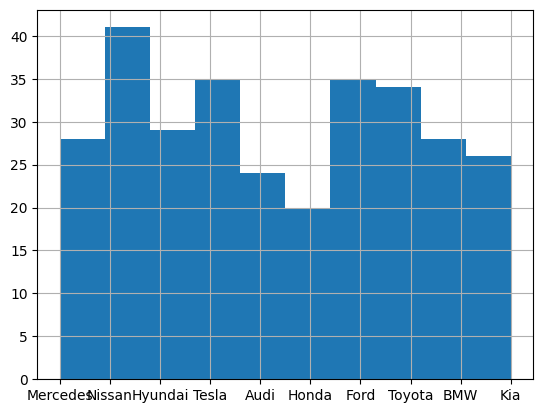

In [ ]:
# histogram
df['Car_Age'].hist()

<Axes: xlabel='Manufacturing_Country'>

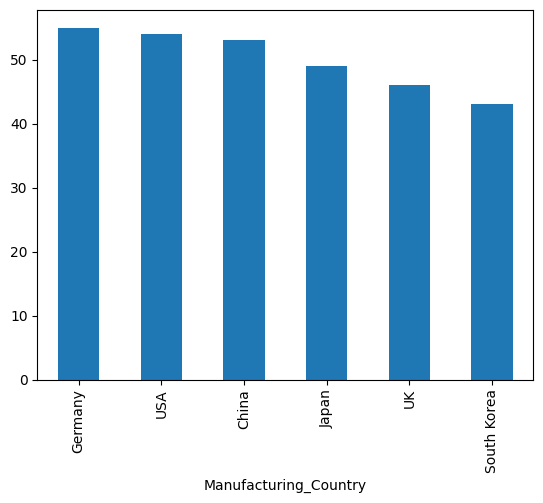

In [54]:
# bar chart
df['Manufacturing_Country'].value_counts().plot(kind='bar')

<Axes: title={'center': 'Horsepower'}, xlabel='Car_Age'>

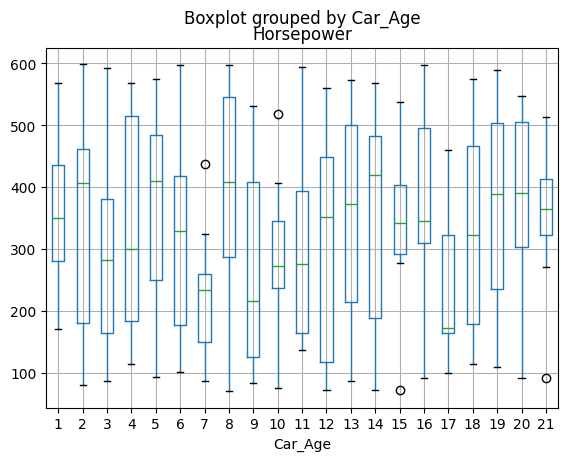

In [58]:
# boxplot
df.boxplot(column='Horsepower', by='Car_Age')

<Axes: xlabel='Car_Age', ylabel='Price_USD'>

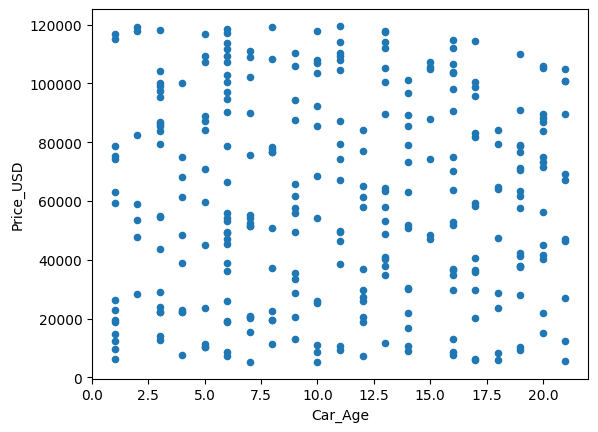

In [59]:
# scatterplot 
df.plot.scatter(x='Car_Age', y='Price_USD')

In [61]:
# correlation matrix heatmap
df.corr(numeric_only=True).style.background_gradient()

,Manufacture_Year,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Car_Age,HP_per_CC,Efficiency_Score
Manufacture_Year,1.000000,0.065402,-0.063101,0.000045,-0.005602,-1.000000,-0.105807,0.000045
Engine_CC,0.065402,1.000000,-0.036996,0.041585,-0.000749,-0.065402,-0.646685,0.041585
Horsepower,-0.063101,-0.036996,1.000000,-0.061263,0.104940,0.063101,0.659153,-0.061263
Mileage_km_per_l,0.000045,0.041585,-0.061263,1.000000,-0.035517,-0.000045,-0.052095,1.000000
Price_USD,-0.005602,-0.000749,0.104940,-0.035517,1.000000,0.005602,0.030636,-0.035517
Car_Age,-1.000000,-0.065402,0.063101,-0.000045,0.005602,1.000000,0.105807,-0.000045
HP_per_CC,-0.105807,-0.646685,0.659153,-0.052095,0.030636,0.105807,1.000000,-0.052095
Efficiency_Score,0.000045,0.041585,-0.061263,1.000000,-0.035517,-0.000045,-0.052095,1.000000


## 7. Time series analysis

In [62]:
df.head()

,Car_ID,Brand,Manufacture_Year,Body_Type,Fuel_Type,Transmission,Engine_CC,Horsepower,Mileage_km_per_l,Price_USD,Manufacturing_Country,Car_Age,Price_Category,HP_per_CC,Age_Category,Efficiency_Score
0,CAR_0001,Mercedes,2006,SUV,Petrol,Manual,4089,547,17,73407,USA,20,Premium,0.1338,Old,0.35
1,CAR_0002,Nissan,2023,Coupe,Petrol,Automatic,4618,167,25,79370,USA,3,Premium,0.0362,New,0.75
2,CAR_0003,Nissan,2007,Hatchback,Diesel,Manual,1802,110,16,76549,China,19,Premium,0.0610,Old,0.30
3,CAR_0004,Nissan,2013,Coupe,Petrol,Manual,1835,373,16,48722,USA,13,Mid-Range,0.2033,Old,0.30
4,CAR_0005,Hyundai,2009,Hatchback,Hybrid,Automatic,2332,145,28,83265,UK,17,Premium,0.0622,Old,0.90


In [65]:
# set date as index
df['Manufacture_Year'] = pd.to_datetime(df['Manufacture_Year'])
df = df.set_index('Manufacture_Year')

In [69]:
# df.resample('ME')['Price_USD'].mean()

In [70]:
# df.asfreq('D').isna().sum()